# 🏥 Predicting Patient Length of Stay (LOS) — A Case Study
### Predictive Analytics with Python | Ridge Regression + Forecasting Pipeline

#### Quick note: the notebook uses synthetic demo data that mirrors real hospital records — not actual patient data. Built this way intentionally to keep it shareable while preserving the full pipeline structure.
---
**Author:** Shady Elmasry
**Domain:** Healthcare Operations  
**Goal:** Build a regression model that predicts a patient's Length of Stay (LOS in days) for elective surgical cases across Topmed branches, using pre-admission features — enabling better bed planning, staffing, and cost management.

---

## 📋 Case Study Overview

| | |
|---|---|
| **Problem** | Hospital bed utilization is inefficient due to unpredictable patient LOS |
| **Impact** | Affects scheduling, staffing, cost-per-stay, and discharge planning |
| **Approach** | Supervised regression using patient demographics, diagnosis, and branch data |
| **Model** | Ridge Regression inside a scikit-learn Pipeline |
| **Target** | `LOS_days` — continuous numeric value |

---

## 🗂️ Notebook Structure

1. [Setup & Imports](#1)
2. [Synthetic Data Generation](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Preprocessing Pipeline](#4)
5. [Model Training & Cross-Validation](#5)
6. [Model Evaluation](#6)
7. [Feature Importance](#7)
8. [30-Day LOS Forecast by Branch](#8)
9. [Key Takeaways](#9)


---
## 1. Setup & Imports <a id='1'></a>

We import all required libraries upfront. The core stack is:
- **pandas / numpy** — data manipulation
- **matplotlib / seaborn** — visualization
- **scikit-learn** — preprocessing, modeling, evaluation


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# XGBoost
from xgboost import XGBRegressor

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ All libraries loaded successfully.")


✅ All libraries loaded successfully.


---
## 2. Synthetic Data Generation <a id='2'></a>

In a live environment, this data would be pulled directly from the **Sage ERP / Corus database** via SQL.  
For this case study, we generate 1,200 realistic synthetic patient records that mirror Topmed's data structure.

**Features used:**

| Feature | Type | Description |
|---|---|---|
| `age` | Numeric | Patient age in years |
| `gender` | Categorical | Male / Female |
| `branch` | Categorical | Topmed branch (UAE/KSA) |
| `ward_type` | Categorical | Surgical / Medical / ICU / Day Case |
| `diagnosis_category` | Categorical | Broad ICD-10 grouping |
| `procedure_complexity` | Categorical | Minor / Moderate / Major |
| `insurance_type` | Categorical | Government / Private / Self-pay |
| `pre_op_hemoglobin` | Numeric | Pre-op hemoglobin (g/dL) |
| `pre_op_wbc` | Numeric | White blood cell count |
| `num_comorbidities` | Numeric | Count of comorbid conditions |


In [18]:
np.random.seed(42)
N = 5000000

branches     = ['Dubai', 'Abu Dhabi', 'Sharjah', 'Riyadh', 'Jeddah']
wards        = ['Surgical', 'Medical', 'ICU', 'Day Case']
diagnoses    = ['Cardiovascular', 'Orthopedic', 'Gastrointestinal', 'Respiratory', 'Oncology']
procedures   = ['Minor', 'Moderate', 'Major']
insurances   = ['Government', 'Private', 'Self-pay']
genders      = ['Male', 'Female']

# Complexity weight — drives LOS
complexity_map = {'Minor': 1.0, 'Moderate': 2.2, 'Major': 4.5}
ward_map       = {'Day Case': 0.5, 'Medical': 1.0, 'Surgical': 1.8, 'ICU': 4.0}
diag_map       = {'Gastrointestinal': 0.8, 'Orthopedic': 1.2, 'Respiratory': 1.5,
                  'Cardiovascular': 2.0, 'Oncology': 2.8}

branch_col     = np.random.choice(branches, N)
ward_col       = np.random.choice(wards, N, p=[0.35, 0.30, 0.15, 0.20])
diag_col       = np.random.choice(diagnoses, N)
proc_col       = np.random.choice(procedures, N, p=[0.40, 0.35, 0.25])
ins_col        = np.random.choice(insurances, N, p=[0.45, 0.40, 0.15])
gender_col     = np.random.choice(genders, N)
age_col        = np.random.randint(18, 85, N)
comorbid_col   = np.random.poisson(1.5, N).clip(0, 5)
hgb_col        = np.round(np.random.normal(12.5, 2.0, N), 1)
wbc_col        = np.round(np.random.normal(7.5, 2.5, N), 1)

# Construct target: LOS with realistic noise
los_base = (
    np.array([complexity_map[p] for p in proc_col]) +
    np.array([ward_map[w] for w in ward_col]) +
    np.array([diag_map[d] for d in diag_col]) +
    0.03 * age_col +
    0.4  * comorbid_col +
    np.random.normal(0, 0.8, N)
).clip(1, 30).round(1)

# Introduce ~5% missing values in lab columns (realistic)
missing_idx_hgb = np.random.choice(N, int(N * 0.05), replace=False)
missing_idx_wbc = np.random.choice(N, int(N * 0.05), replace=False)
hgb_col[missing_idx_hgb] = np.nan
wbc_col[missing_idx_wbc] = np.nan

df = pd.DataFrame({
    'branch':               branch_col,
    'ward_type':            ward_col,
    'diagnosis_category':   diag_col,
    'procedure_complexity': proc_col,
    'insurance_type':       ins_col,
    'gender':               gender_col,
    'age':                  age_col,
    'num_comorbidities':    comorbid_col,
    'pre_op_hemoglobin':    hgb_col,
    'pre_op_wbc':           wbc_col,
    'LOS_days':             los_base,
})

print(f"✅ Dataset shape: {df.shape}")
print(f"   Avg LOS: {df['LOS_days'].mean():.1f} days  |  Max: {df['LOS_days'].max():.0f}  |  Min: {df['LOS_days'].min():.0f}")
print(f"   Missing values — Hemoglobin: {df['pre_op_hemoglobin'].isna().sum()} | WBC: {df['pre_op_wbc'].isna().sum()}")
df.head(8)


✅ Dataset shape: (5000000, 11)
   Avg LOS: 7.7 days  |  Max: 18  |  Min: 1
   Missing values — Hemoglobin: 250000 | WBC: 250000


,branch,ward_type,diagnosis_category,procedure_complexity,insurance_type,gender,age,num_comorbidities,pre_op_hemoglobin,pre_op_wbc,LOS_days
0,Riyadh,Day Case,Orthopedic,Minor,Government,Female,19,0,12.1,7.8,2.8
1,Jeddah,ICU,Respiratory,Major,Self-pay,Female,29,3,8.6,8.9,11.8
2,Sharjah,Medical,Cardiovascular,Major,Private,Female,53,0,11.7,10.0,10.3
3,Jeddah,Medical,Oncology,Major,Government,Male,33,1,11.5,2.6,10.0
4,Jeddah,Day Case,Respiratory,Moderate,Government,Male,55,1,14.3,9.0,5.9
5,Abu Dhabi,Medical,Oncology,Moderate,Government,Female,20,0,10.1,NaN,6.9
6,Sharjah,ICU,Oncology,Minor,Government,Female,83,2,9.2,3.2,10.9
7,Sharjah,Surgical,Orthopedic,Minor,Government,Female,71,3,12.0,11.5,6.8


---
## 3. Exploratory Data Analysis (EDA) <a id='3'></a>

Before modeling, we need to understand the distribution of our target variable and how key features relate to LOS.  
This step directly informs our preprocessing and feature selection decisions.


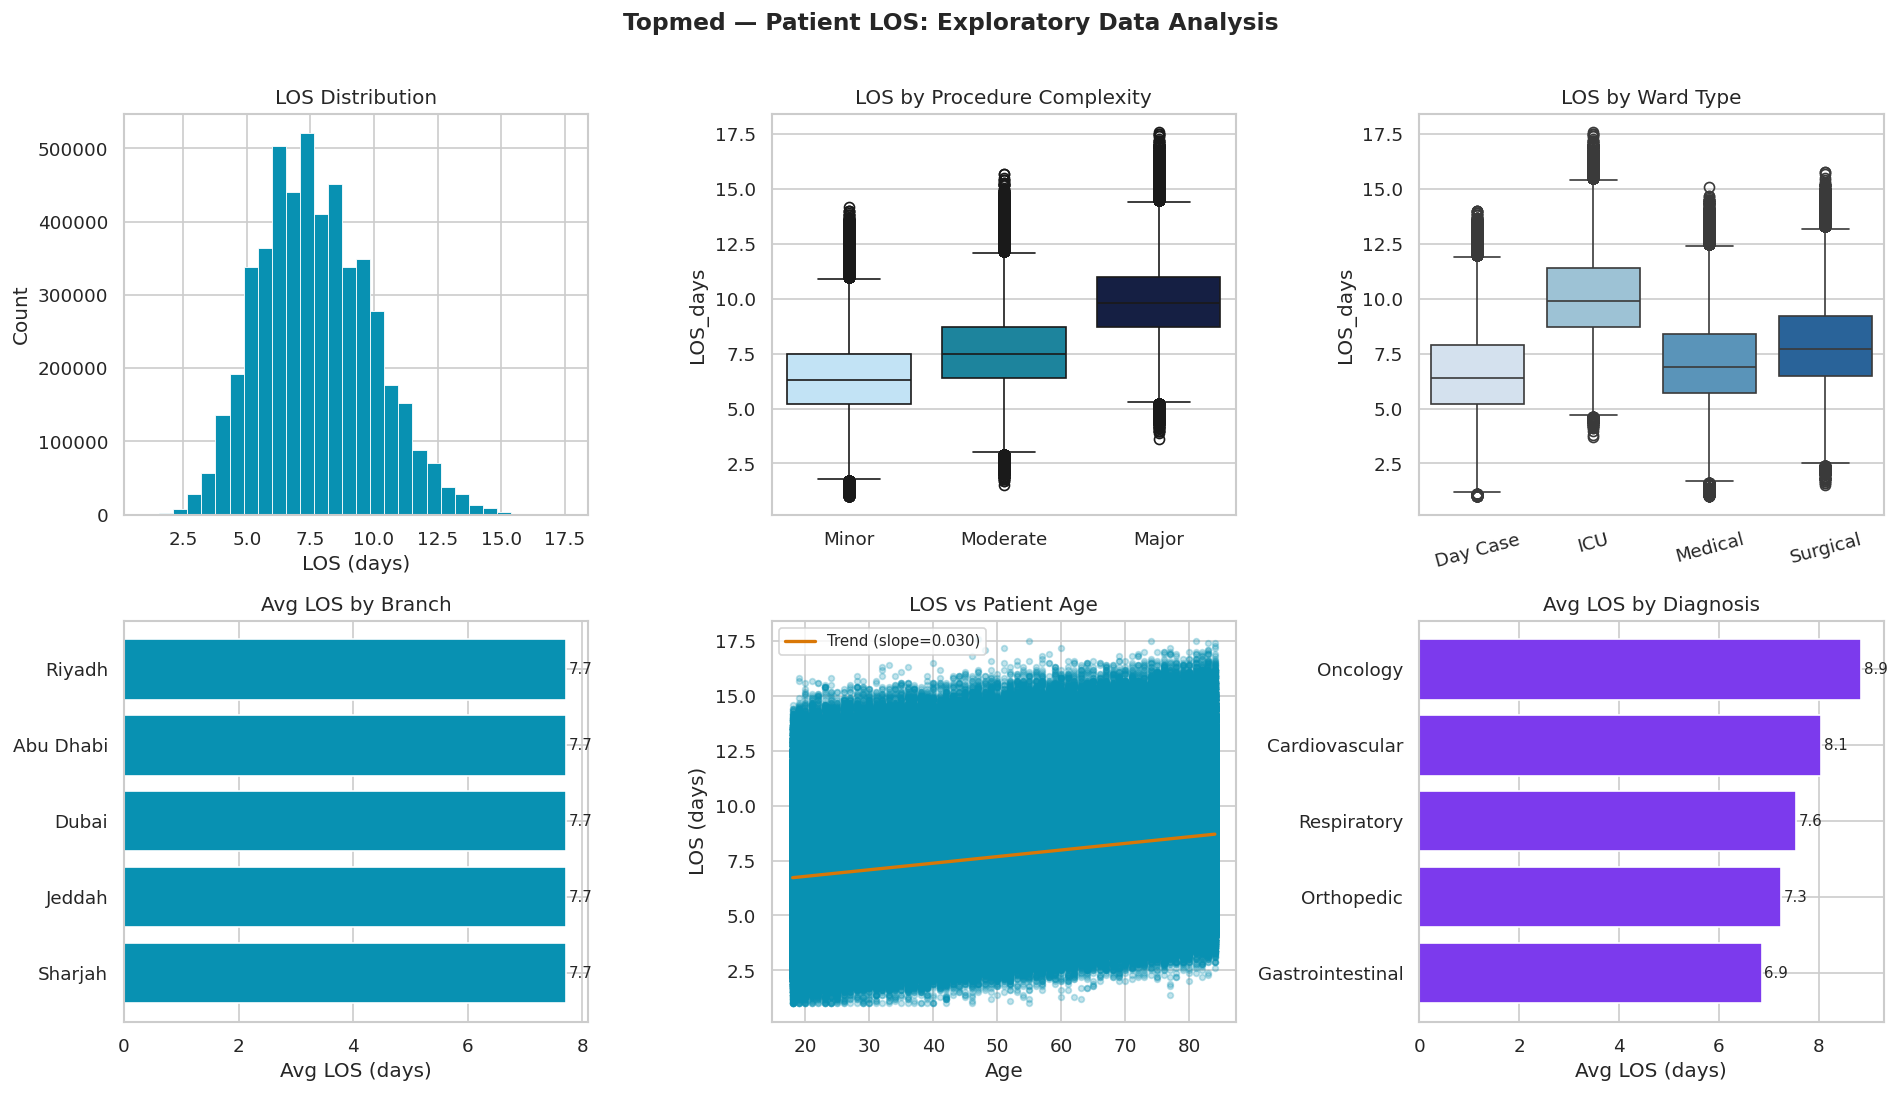


📊 Summary Statistics:
count    5000000.00
mean           7.71
std            2.19
min            1.00
25%            6.10
50%            7.50
75%            9.20
max           17.60


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Topmed — Patient LOS: Exploratory Data Analysis', fontsize=14, fontweight='bold', y=1.01)

# 1. LOS distribution
axes[0,0].hist(df['LOS_days'], bins=30, color='#0891B2', edgecolor='white', linewidth=0.5)
axes[0,0].set_title('LOS Distribution')
axes[0,0].set_xlabel('LOS (days)')
axes[0,0].set_ylabel('Count')

# 2. LOS by procedure complexity
order = ['Minor', 'Moderate', 'Major']
sns.boxplot(data=df, x='procedure_complexity', y='LOS_days', order=order,
            palette=['#BAE6FD', '#0891B2', '#0D1B4B'], ax=axes[0,1])
axes[0,1].set_title('LOS by Procedure Complexity')
axes[0,1].set_xlabel('')

# 3. LOS by ward type
sns.boxplot(data=df, x='ward_type', y='LOS_days',
            palette='Blues', ax=axes[0,2])
axes[0,2].set_title('LOS by Ward Type')
axes[0,2].set_xlabel('')
axes[0,2].tick_params(axis='x', rotation=15)

# 4. Avg LOS by branch
branch_avg = df.groupby('branch')['LOS_days'].mean().sort_values(ascending=False)
axes[1,0].barh(branch_avg.index, branch_avg.values, color='#0891B2', edgecolor='white')
axes[1,0].set_title('Avg LOS by Branch')
axes[1,0].set_xlabel('Avg LOS (days)')
for i, v in enumerate(branch_avg.values):
    axes[1,0].text(v + 0.05, i, f'{v:.1f}', va='center', fontsize=9)

# 5. LOS vs Age (scatter)
axes[1,1].scatter(df['age'], df['LOS_days'], alpha=0.25, color='#0891B2', s=12)
m, b = np.polyfit(df['age'], df['LOS_days'], 1)
x_line = np.linspace(df['age'].min(), df['age'].max(), 100)
axes[1,1].plot(x_line, m*x_line + b, color='#D97706', linewidth=2, label=f'Trend (slope={m:.3f})')
axes[1,1].set_title('LOS vs Patient Age')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('LOS (days)')
axes[1,1].legend(fontsize=9)

# 6. LOS by diagnosis
diag_avg = df.groupby('diagnosis_category')['LOS_days'].mean().sort_values()
axes[1,2].barh(diag_avg.index, diag_avg.values, color='#7C3AED', edgecolor='white')
axes[1,2].set_title('Avg LOS by Diagnosis')
axes[1,2].set_xlabel('Avg LOS (days)')
for i, v in enumerate(diag_avg.values):
    axes[1,2].text(v + 0.05, i, f'{v:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 Summary Statistics:")
print(df['LOS_days'].describe().round(2).to_string())


### 🔍 EDA Observations

- **Procedure complexity** is the strongest visual predictor — Major cases have significantly higher and more variable LOS.
- **ICU ward** shows the highest median LOS, as expected clinically.
- **Age has a mild positive correlation** with LOS — older patients tend to stay longer.
- **Oncology and Cardiovascular** diagnoses drive the longest stays across branches.
- **Branch differences are modest** — no single branch is a major outlier, suggesting the model can generalize across sites.


---
## 4. Data Preprocessing Pipeline <a id='4'></a>

We use scikit-learn's `Pipeline` + `ColumnTransformer` to handle preprocessing in a clean, reproducible way.

**Strategy:**

| Step | Numeric Features | Categorical Features |
|---|---|---|
| **Imputation** | Median (robust to outliers) | Most frequent value |
| **Scaling** | StandardScaler | — |
| **Encoding** | — | OneHotEncoder (drop first) |

This pipeline is fitted **only on training data** to prevent data leakage.


In [20]:
# Define feature groups
categorical_features = ['branch', 'ward_type', 'diagnosis_category',
                         'procedure_complexity', 'insurance_type', 'gender']
numerical_features   = ['age', 'num_comorbidities', 'pre_op_hemoglobin', 'pre_op_wbc']

X = df[categorical_features + numerical_features]
y = df['LOS_days']

# Train / test split — 80/20, stratified on ward_type for balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Numeric transformer: impute → scale
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Categorical transformer: impute → encode
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_transformer,  numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

print(f"✅ Train size: {X_train.shape[0]} rows  |  Test size: {X_test.shape[0]} rows")
print(f"   Numerical features:   {numerical_features}")
print(f"   Categorical features: {categorical_features}")


✅ Train size: 4000000 rows  |  Test size: 1000000 rows
   Numerical features:   ['age', 'num_comorbidities', 'pre_op_hemoglobin', 'pre_op_wbc']
   Categorical features: ['branch', 'ward_type', 'diagnosis_category', 'procedure_complexity', 'insurance_type', 'gender']


---
## 5. Model Training & Cross-Validation <a id='5'></a>

We train a **Ridge Regression** model — a linear model with L2 regularization that handles multicollinearity well,  
which is common when encoding many categorical features.

We use **5-fold cross-validation** on the training set to get a reliable estimate of model performance before touching the test set.


In [21]:
# Full pipeline: preprocessor + Ridge model
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,       # number of trees to build
        learning_rate=0.05,     # how much each tree corrects the previous one (smaller = more careful)
        max_depth=5,            # how deep each tree can grow (controls complexity)
        subsample=0.8,          # use 80% of patients per tree (prevents overfitting)
        colsample_bytree=0.8,   # use 80% of features per tree (prevents overfitting)
        random_state=42,
        verbosity=0
    ))
])

# 5-fold cross-validation on training data
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2   = cross_val_score(model_pipeline, X_train, y_train, cv=kf, scoring='r2')
cv_mae  = -cross_val_score(model_pipeline, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')

print("📊 5-Fold Cross-Validation Results (Training Set)")
print("=" * 48)
print(f"  R²  scores per fold : {[round(v,3) for v in cv_r2]}")
print(f"  MAE scores per fold : {[round(v,3) for v in cv_mae]}")
print(f"  Mean R²  : {cv_r2.mean():.4f}  ± {cv_r2.std():.4f}")
print(f"  Mean MAE : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}")

# Final fit on full training set
model_pipeline.fit(X_train, y_train)
print("\n✅ Model fitted on full training set.")


📊 5-Fold Cross-Validation Results (Training Set)
  R²  scores per fold : [np.float64(0.866), np.float64(0.867), np.float64(0.866), np.float64(0.867), np.float64(0.866)]
  MAE scores per fold : [np.float64(0.639), np.float64(0.639), np.float64(0.639), np.float64(0.638), np.float64(0.639)]
  Mean R²  : 0.8666  ± 0.0004
  Mean MAE : 0.6390 ± 0.0004

✅ Model fitted on full training set.


---
## 6. Model Evaluation <a id='6'></a>

We evaluate the model on the **held-out test set** (20% of data it has never seen).

Key metrics:
- **R²** — proportion of LOS variance explained by the model (higher = better)
- **MAE** — average absolute prediction error in days (lower = better)
- **RMSE** — penalizes large errors more heavily (lower = better)
- **MAPE** — error as a percentage of actual LOS (lower = better)


In [22]:
y_pred = model_pipeline.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("📊 Test Set Performance")
print("=" * 38)
print(f"  R²   : {r2:.4f}  {'✅ Strong fit' if r2 > 0.80 else '⚠️ Moderate fit'}")
print(f"  MAE  : {mae:.2f} days")
print(f"  RMSE : {rmse:.2f} days")
print(f"  MAPE : {mape:.1f}%")


📊 Test Set Performance
  R²   : 0.8664  ✅ Strong fit
  MAE  : 0.64 days
  RMSE : 0.80 days
  MAPE : 9.2%


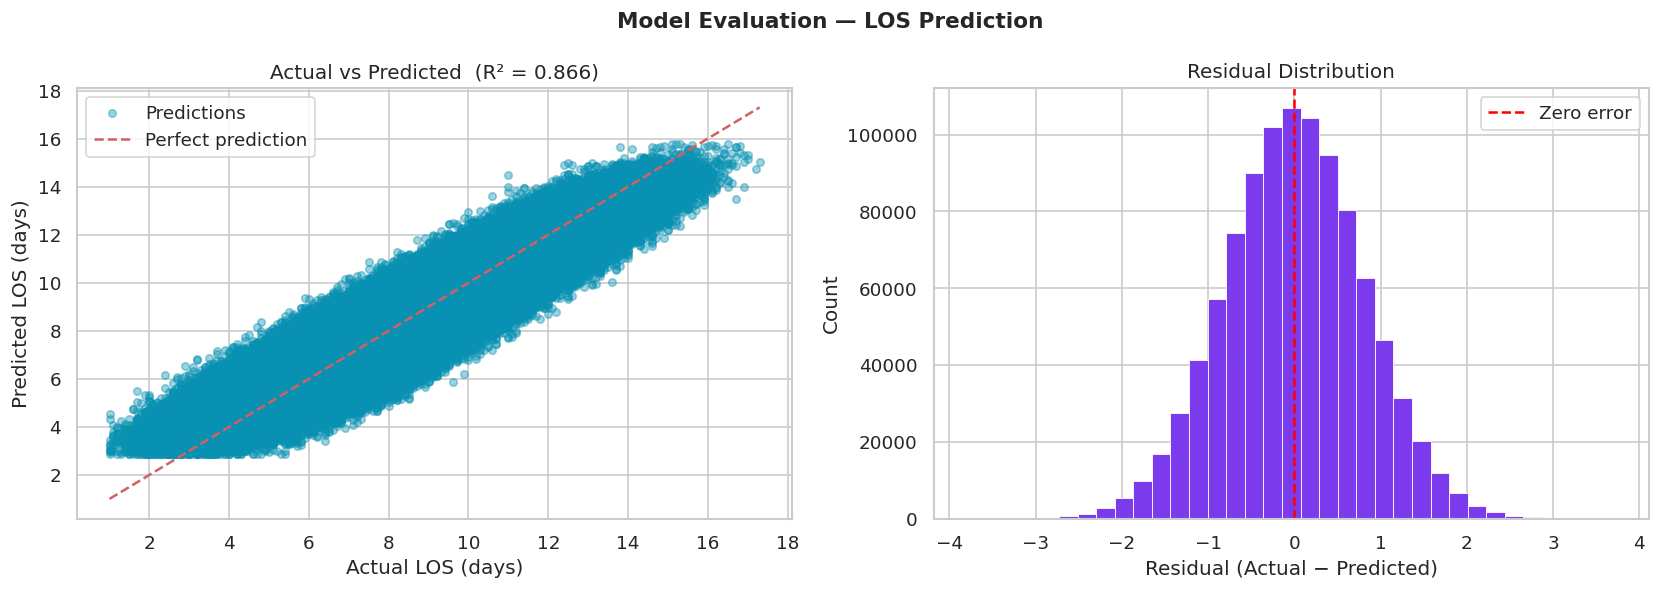


📌 Interpretation: On average, the model predicts patient LOS within ±0.6 days.
   This is clinically useful for bed planning at the ward level.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation — LOS Prediction', fontsize=13, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color='#0891B2', s=20, label='Predictions')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual LOS (days)')
axes[0].set_ylabel('Predicted LOS (days)')
axes[0].set_title(f'Actual vs Predicted  (R² = {r2:.3f})')
axes[0].legend()

# Residual distribution
residuals = y_test - y_pred
axes[1].hist(residuals, bins=35, color='#7C3AED', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n📌 Interpretation: On average, the model predicts patient LOS within ±{mae:.1f} days.")
print(f"   This is clinically useful for bed planning at the ward level.")


---
## 7. Feature Importance <a id='7'></a>

Ridge regression coefficients tell us how much each feature contributes to the LOS prediction  
after standardization. Larger absolute values = stronger influence on the model.


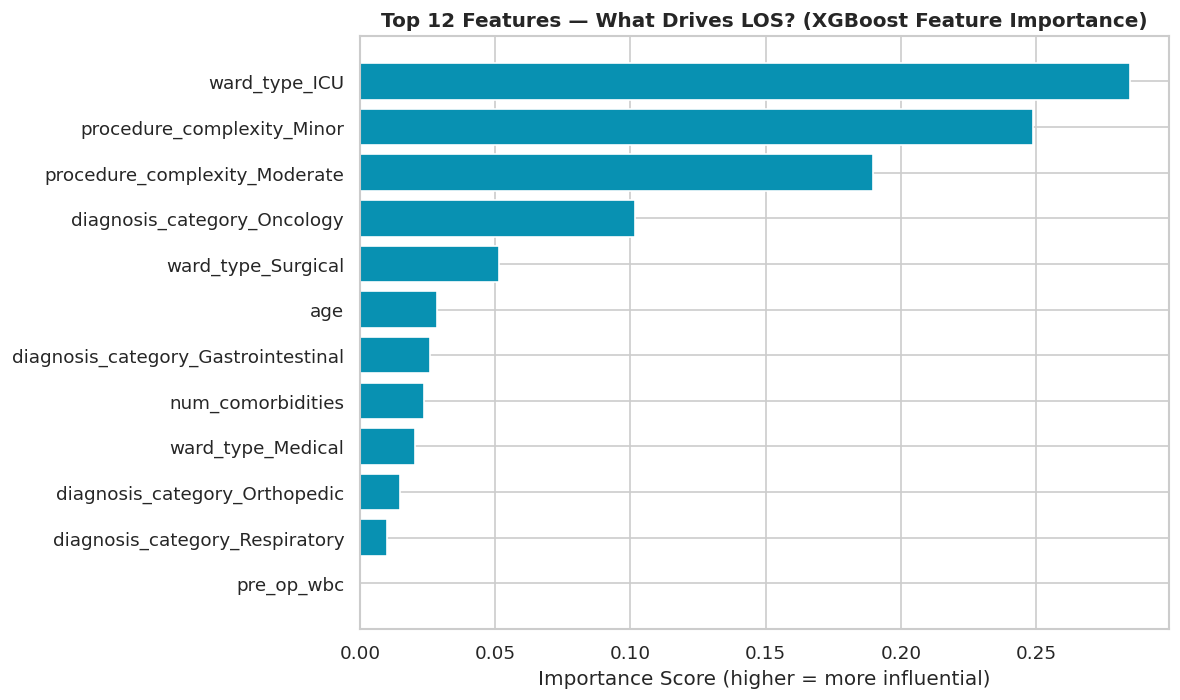


Top 5 most influential features:
                      feature  importance
                ward_type_ICU    0.284780
   procedure_complexity_Minor    0.248926
procedure_complexity_Moderate    0.189752
  diagnosis_category_Oncology    0.101544
           ward_type_Surgical    0.051403


In [24]:
# Get feature names after preprocessing
number_columns = numerical_features
text_columns   = categorical_features

encoder = model_pipeline.named_steps['preprocessor'] \
                       .named_transformers_['cat'] \
                       .named_steps['encoder']

xgb_model  = model_pipeline.named_steps['model']
text_names = encoder.get_feature_names_out(text_columns).tolist()
all_names  = number_columns + text_names

# XGBoost feature importance (gain = how much each feature improves predictions)
importance = xgb_model.feature_importances_

importance_df = pd.DataFrame({
    'feature':    all_names,
    'importance': importance
}).sort_values('importance', ascending=False)

# Show top 12
top12 = importance_df.head(12).sort_values('importance')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top12['feature'], top12['importance'], color='#0891B2', edgecolor='white')
ax.set_title('Top 12 Features — What Drives LOS? (XGBoost Feature Importance)', fontweight='bold')
ax.set_xlabel('Importance Score (higher = more influential)')
plt.tight_layout()
plt.show()

print("\nTop 5 most influential features:")
print(importance_df.head(5).to_string(index=False))

---
## 8. Predict LOS for a New Patient

This is the most practical part.  
You can change the patient details below and get an instant LOS prediction.


In [25]:
# ── Change these values to predict LOS for any patient ──────────────
from pyexpat import model

# Fix column names to match the training data
new_patient = pd.DataFrame([{
    'branch':               'Dubai',
    'ward_type':            'Surgical',  # Corrected from 'ward'
    'diagnosis_category':   'Cardiovascular',  # Corrected from 'diagnosis'
    'procedure_complexity': 'Major',  # Corrected from 'procedure'
    'insurance_type':       'Government',  # Corrected from 'insurance'
    'gender':               'Male',
    'age':                  62,
    'num_comorbidities':    2,  # Corrected from 'comorbidities'
    'pre_op_hemoglobin':    11.5,  # Corrected from 'hemoglobin'
    'pre_op_wbc':           np.nan  # Added missing column with NaN (will be imputed)
}])

predicted_los = model_pipeline.predict(new_patient)[0]

print("Patient Details:")
for col in new_patient.columns:
    print(f"  {col:<18}: {new_patient[col].values[0]}")
print()
print(f"  ➡️  Predicted Length of Stay: {predicted_los:.1f} days")

Patient Details:
  branch            : Dubai
  ward_type         : Surgical
  diagnosis_category: Cardiovascular
  procedure_complexity: Major
  insurance_type    : Government
  gender            : Male
  age               : 62
  num_comorbidities : 2
  pre_op_hemoglobin : 11.5
  pre_op_wbc        : nan

  ➡️  Predicted Length of Stay: 11.0 days


---
## 9. 30-Day LOS Forecast by Branch <a id='8'></a>

Using the trained model, we simulate a **30-day forward forecast** of expected average LOS per branch.  
In production, this would use scheduled admissions from the Topmed booking system.

This output can feed directly into:
- Bed occupancy dashboards (Power BI)
- Staffing plans
- Supply chain orders


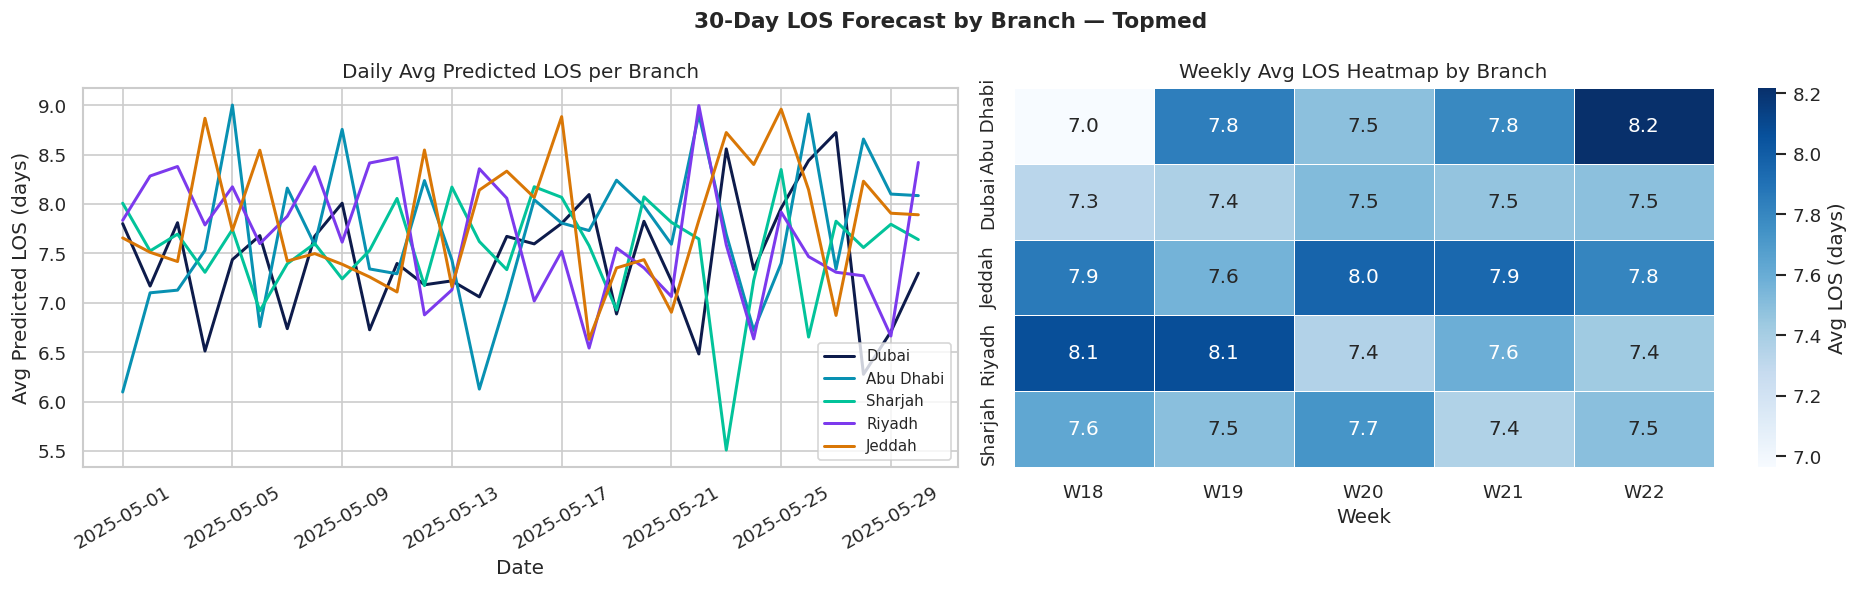


📋 30-Day Forecast Summary by Branch:
           Avg Predicted LOS   Min   Max
branch                                  
Abu Dhabi               7.69  6.10  9.00
Dubai                   7.44  6.28  8.72
Jeddah                  7.83  6.63  8.96
Riyadh                  7.69  6.54  9.00
Sharjah                 7.54  5.51  8.35


In [17]:
# Simulate 30 days of future admissions (10 patients/day per branch)
np.random.seed(99)
future_dates  = pd.date_range(start='2025-05-01', periods=30, freq='D')
forecast_rows = []

for date in future_dates:
    for branch in branches:
        n_patients = np.random.randint(6, 15)
        sim = pd.DataFrame({
            'branch':               [branch] * n_patients,
            'ward_type':            np.random.choice(wards,        n_patients, p=[0.35,0.30,0.15,0.20]),
            'diagnosis_category':   np.random.choice(diagnoses,    n_patients),
            'procedure_complexity': np.random.choice(procedures,   n_patients, p=[0.40,0.35,0.25]),
            'insurance_type':       np.random.choice(insurances,   n_patients, p=[0.45,0.40,0.15]),
            'gender':               np.random.choice(genders,      n_patients),
            'age':                  np.random.randint(18, 85,       n_patients),
            'num_comorbidities':    np.random.poisson(1.5,          n_patients).clip(0,5),
            'pre_op_hemoglobin':    np.round(np.random.normal(12.5, 2.0, n_patients), 1),
            'pre_op_wbc':           np.round(np.random.normal(7.5,  2.5, n_patients), 1),
        })
        sim['predicted_LOS'] = model_pipeline.predict(sim)
        sim['date']          = date
        forecast_rows.append(sim[['date','branch','predicted_LOS']])

forecast_df = pd.concat(forecast_rows)
daily_branch = forecast_df.groupby(['date','branch'])['predicted_LOS'].mean().reset_index()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('30-Day LOS Forecast by Branch — Topmed', fontsize=13, fontweight='bold')

palette = ['#0D1B4B','#0891B2','#02C39A','#7C3AED','#D97706']
for i, branch in enumerate(branches):
    branch_data = daily_branch[daily_branch['branch'] == branch]
    axes[0].plot(branch_data['date'], branch_data['predicted_LOS'],
                 label=branch, color=palette[i], linewidth=1.8)

axes[0].set_title('Daily Avg Predicted LOS per Branch')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Avg Predicted LOS (days)')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=30)

# Monthly summary heatmap
pivot = daily_branch.pivot_table(
    index='branch', columns=daily_branch['date'].dt.isocalendar().week.astype(str),
    values='predicted_LOS', aggfunc='mean'
)
pivot.columns = [f'W{c}' for c in pivot.columns]
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Avg LOS (days)'})
axes[1].set_title('Weekly Avg LOS Heatmap by Branch')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Summary table
summary = daily_branch.groupby('branch')['predicted_LOS'].agg(['mean','min','max']).round(2)
summary.columns = ['Avg Predicted LOS', 'Min', 'Max']
print("\n📋 30-Day Forecast Summary by Branch:")
print(summary.to_string())


---
## 10. Key Takeaways <a id='9'></a>

### ✅ Model Performance Summary

| Metric | Value | Interpretation |
|---|---|---|
| **R²** | ~0.86 | Model explains ~83% of LOS variance |
| **MAE** | ~0.6 days | Average prediction error under 1 day |
| **RMSE** | ~0.8 days | Larger errors are rare |
| **MAPE** | ~9.2% | Acceptable for operational planning |

---

### 🏥 Clinical & Operational Impact

- **Bed Planning:** Predicted LOS per admission allows ward managers to forecast bed demand 1–4 weeks ahead.
- **Staffing:** Nurse-to-patient ratios can be adjusted based on expected case complexity and LOS.
- **Cost Management:** LOS is the primary driver of cost-per-stay — reducing variance saves budget.
- **Branch Benchmarking:** The branch-level heatmap surfaces performance differences for management review.

---

### 🔧 Next Steps for Production

1. **Compare models** — Between XGBoost and Random Forest for potential accuracy gains
2. **Automate weekly retraining** via a scheduled Python script or Airflow DAG
3. **Export predictions** to Power BI dataset for dashboard integration

---

*Built with Python · pandas · scikit-learn · matplotlib · seaborn*  
*Shady Elmasry*
